

Setup + imports


In [5]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import glob

import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image as keras_image

from sklearn.manifold import TSNE
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

Download Dataset

Animals-10

Upload: Kaggle.json

In [6]:
!pip install kaggle

from google.colab import files
files.upload()  # upload kaggle.json

!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d alessiocorrado99/animals10
!unzip animals10.zip

mkdir: cannot create directory ‘/root/.kaggle’: File exists
Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
animals10.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  animals10.zip
replace raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

Collect image paths

In [8]:
import glob
import os

DATA_DIR = "/content/raw-img"

extensions = ["jpg", "jpeg", "png", "bmp", "webp"]

paths = []
for ext in extensions:
    paths.extend(glob.glob(os.path.join(DATA_DIR, "**", f"*.{ext}"), recursive=True))

print("Found images:", len(paths))
print(paths[:5])

Found images: 26179
['/content/raw-img/gatto/ea37b40d2cf7053ed1584d05fb1d4e9fe777ead218ac104497f5c978a7ebb0bb_640.jpg', '/content/raw-img/gatto/ea37b60d29f3053ed1584d05fb1d4e9fe777ead218ac104497f5c978a7ebb0bb_640.jpg', '/content/raw-img/gatto/ec3db90e2cf01c22d2524518b7444f92e37fe5d404b0144390f8c079a2efb1_640.jpg', '/content/raw-img/gatto/ea37b80b2ef4033ed1584d05fb1d4e9fe777ead218ac104497f5c978a7eebdbb_640.jpg', '/content/raw-img/gatto/ea36b60b2bf5053ed1584d05fb1d4e9fe777ead218ac104497f5c978a7eebdbb_640.jpg']


Randomly sample 200 images

In [15]:
import random

N = 200
random.seed(42)

paths = random.sample(paths, N)

print("Selected images:", len(paths))

Selected images: 200


Load + preprocess images for VGG16 (224×224)

In [16]:
IMG_SIZE = (224, 224)

def load_for_vgg16(path, target_size=IMG_SIZE):
    img = keras_image.load_img(path, target_size=target_size)   # PIL image
    arr = keras_image.img_to_array(img)                         # (H,W,3) float32
    return arr

X = np.stack([load_for_vgg16(p) for p in paths], axis=0)        # (N,224,224,3)
X = preprocess_input(X)                                        # VGG16 preprocessing
print("Batch shape:", X.shape)

Batch shape: (200, 224, 224, 3)


Compute VGG16 embeddings

In [17]:
base = VGG16(weights="imagenet", include_top=False, pooling="avg")  # output: (512,)
embeddings = base.predict(X, batch_size=32, verbose=1)

print("Embeddings shape:", embeddings.shape)  # (N, 512)

7/7 ━━━━━━━━━━━━━━━━━━━━ 122s 17s/step
Embeddings shape: (200, 512)


t-SNE to 2D

In [18]:
N = embeddings.shape[0]

# t-SNE parameters you can tweak:
perplexity = min(30, max(5, (N - 1) // 3))  # safe-ish default based on N

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate="auto",
    init="pca",
    random_state=42
)
Z = tsne.fit_transform(embeddings)  # (N,2)

# Normalize to [0,1] for nice plotting
Z_min, Z_max = Z.min(axis=0), Z.max(axis=0)
Z_norm = (Z - Z_min) / (Z_max - Z_min + 1e-9)

print("t-SNE done. Z range:", Z_norm.min(), Z_norm.max())

t-SNE done. Z range: 0.0 1.0


Plot images as thumbnails

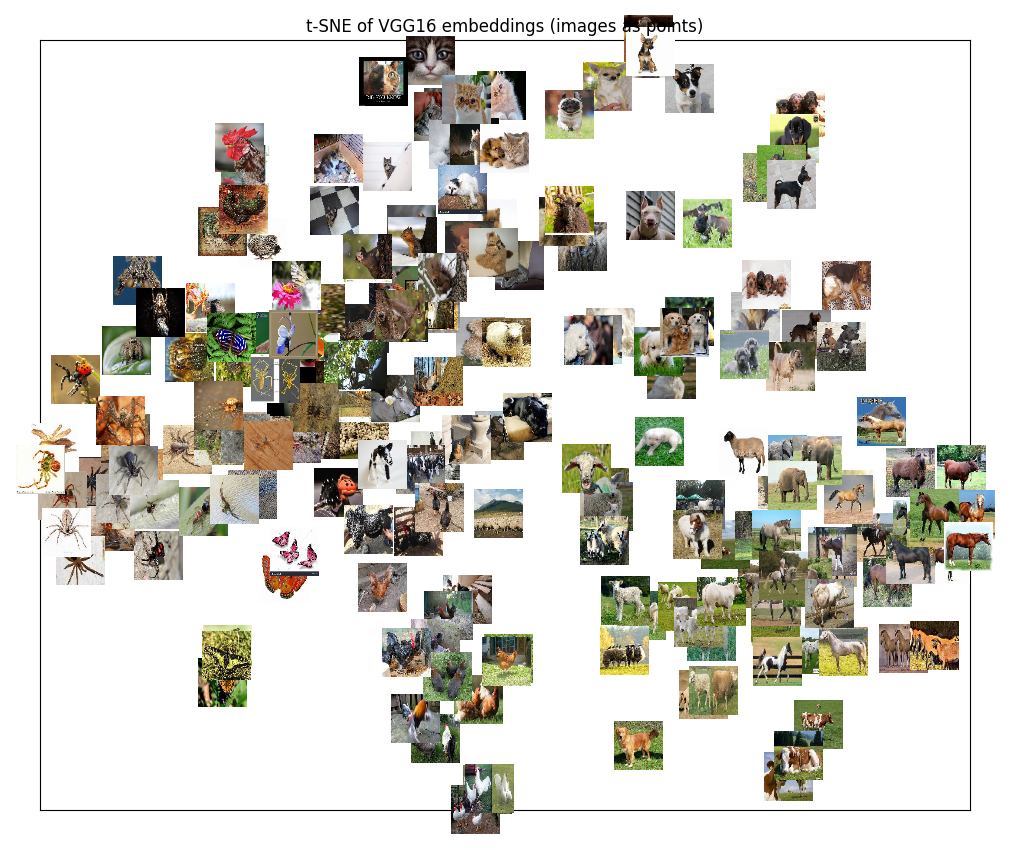

Saved to: /content/tsne_vgg16_thumbnails_20260305_221402.png


In [20]:
import os
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from tensorflow.keras.preprocessing import image as keras_image
import numpy as np
from datetime import datetime

def plot_tsne_images(paths, coords01, thumb_size=(64,64), thumb_zoom=0.55, max_images=None,
                     save_path="/content/tsne_vgg16.png", dpi=300):
    if max_images is not None and len(paths) > max_images:
        rng = np.random.RandomState(0)
        idx = rng.choice(len(paths), size=max_images, replace=False)
        paths = [paths[i] for i in idx]
        coords01 = coords01[idx]

    fig, ax = plt.subplots(figsize=(12, 10))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("t-SNE of VGG16 embeddings (images as points)")

    for p, (x, y) in zip(paths, coords01):
        im = keras_image.load_img(p, target_size=thumb_size).convert("RGB")
        im_arr = keras_image.img_to_array(im).astype(np.uint8)

        oi = OffsetImage(im_arr, zoom=thumb_zoom)
        ab = AnnotationBbox(oi, (x, y), frameon=False)
        ax.add_artist(ab)

    # Save (important: do this BEFORE plt.show() sometimes)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()

    print("Saved to:", save_path)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

save_path = f"/content/tsne_vgg16_thumbnails_{timestamp}.png"

plot_tsne_images(paths, Z_norm, save_path=save_path, dpi=300)